<a href="https://colab.research.google.com/github/skander98/Data_Analytic/blob/main/HIFI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf content/HiFi_IFDL


In [2]:
!rm -rf HiFi_IFDL

In [3]:
!git clone https://github.com/CHELSEA234/HiFi_IFDL.git
%cd HiFi_IFDL

Cloning into 'HiFi_IFDL'...
remote: Enumerating objects: 464, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 464 (delta 19), reused 5 (delta 4), pack-reused 435 (from 2)
Receiving objects: 100% (464/464), 97.79 MiB | 14.22 MiB/s, done.
Resolving deltas: 100% (161/161), done.
Updating files: 100% (187/187), done.
/content/HiFi_IFDL


In [4]:
%cd HiFi_IFDL

[Errno 2] No such file or directory: 'HiFi_IFDL'
/content/HiFi_IFDL


In [5]:
!pip -q install opencv-python pillow numpy scipy scikit-image matplotlib tqdm yacs tensorboardX gdown
!pip install kmeans-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.0 MB/s eta 0:00:00


In [6]:
!sed -i 's/np.int(/int(/g' models/seg_hrnet.py
!grep -R "np.int(" -n . || echo "OK: no np.int("


./applications/deepfake_detection/sequence/models/hrnet/seg_hrnet.py:413:        # last_inp_channels = np.int(np.sum(pre_stage_channels))


In [7]:
!pip -q install gdown
!rm -rf downloaded_weights weights
!mkdir -p downloaded_weights weights

!gdown --folder "https://drive.google.com/drive/folders/1v07aJ2hKmSmboceVwOhPvjebFMJFHyhm" -O downloaded_weights


Retrieving folder contents
Retrieving folder 1yBiqlmC8rzoYzapPQgAJonFgeViAGWLZ HRNet
Processing file 1BSg39gzlUM_odiiuV5NIJoc8f90JCCqf 750001.pth
Retrieving folder 1KeI8MVTRbg1Rrl9-5vOUoniBzinLL3Cy NLCDetection
Processing file 1hELPa0bIyLrnr0a06vmr6GWNNinWB0nf 750001.pth
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1BSg39gzlUM_odiiuV5NIJoc8f90JCCqf
From (redirected): https://drive.google.com/uc?id=1BSg39gzlUM_odiiuV5NIJoc8f90JCCqf&confirm=t&uuid=4e5c919f-7071-4dde-b3e1-a15e9d59f7ab
To: /content/HiFi_IFDL/downloaded_weights/HRNet/750001.pth
100% 81.1M/81.1M [00:03<00:00, 20.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1hELPa0bIyLrnr0a06vmr6GWNNinWB0nf
From (redirected): https://drive.google.com/uc?id=1hELPa0bIyLrnr0a06vmr6GWNNinWB0nf&confirm=t&uuid=690c7fa4-5192-43fb-b1cd-99eef8c75cb7
To: /content/HiFi_IFDL/downloaded_weights/NLCDetection/75

In [8]:
!mkdir -p weights
!cp -r downloaded_weights/HRNet weights/HRNet
!cp -r downloaded_weights/NLCDetection weights/NLCDetection

# Vérifie qu'on a bien des checkpoints
!find weights -type f \( -name "*.pth" -o -name "*.pt" \) -print


weights/NLCDetection/750001.pth
weights/HRNet/750001.pth


In [9]:
!ls -l models | head -n 50
!test -f models/hrnet_w18_small_v2.pth && echo "OK: hrnet_w18_small_v2.pth present" || echo "WARNING: hrnet_w18_small_v2.pth missing"


total 15720
-rw-r--r-- 1 root root     2768 Feb 12 19:10 GaussianSmoothing.py
-rw-r--r-- 1 root root 16012341 Feb 12 19:10 hrnet_w18_small_v2.pth
-rw-r--r-- 1 root root     2370 Feb 12 19:10 LaPlacianMs.py
-rw-r--r-- 1 root root    11914 Feb 12 19:10 NLCDetection_api.py
-rw-r--r-- 1 root root    16203 Feb 12 19:10 NLCDetection_loc.py
-rw-r--r-- 1 root root    12017 Feb 12 19:10 NLCDetection_pconv.py
drwxr-xr-x 2 root root     4096 Feb 12 19:10 __pycache__
-rw-r--r-- 1 root root     1752 Feb 12 19:10 seg_hrnet_config.py
-rw-r--r-- 1 root root    22855 Feb 12 19:10 seg_hrnet.py
OK: hrnet_w18_small_v2.pth present


In [10]:
!find weights -maxdepth 4 -type f -print


weights/NLCDetection/750001.pth
weights/HRNet/750001.pth


In [11]:
!ls -R weights | head -n 200


weights:
HRNet
NLCDetection

weights/HRNet:
750001.pth

weights/NLCDetection:
750001.pth


In [12]:
!ls -la
!ls -R downloaded_weights | head -n 200


total 116
drwxr-xr-x 14 root root 4096 Feb 12 19:10 .
drwxr-xr-x  1 root root 4096 Feb 12 19:10 ..
drwxr-xr-x  5 root root 4096 Feb 12 19:10 applications
drwxr-xr-x  2 root root 4096 Feb 12 19:10 asset
drwxr-xr-x  2 root root 4096 Feb 12 19:10 center
drwxr-xr-x  2 root root 4096 Feb 12 19:10 center_loc
drwxr-xr-x  7 root root 4096 Feb 12 19:10 data_dir
drwxr-xr-x  4 root root 4096 Feb 12 19:10 downloaded_weights
-rw-r--r--  1 root root 8196 Feb 12 19:10 .DS_Store
-rw-r--r--  1 root root 4229 Feb 12 19:10 environment.yml
drwxr-xr-x  2 root root 4096 Feb 12 19:10 figures
drwxr-xr-x  8 root root 4096 Feb 12 19:10 .git
-rw-r--r--  1 root root 9134 Feb 12 19:10 HiFi_Net_loc.py
-rw-r--r--  1 root root  106 Feb 12 19:10 HiFi_Net_loc.sh
-rw-r--r--  1 root root 4774 Feb 12 19:10 HiFi_Net.py
-rw-r--r--  1 root root 1810 Feb 12 19:10 IMD_dataloader.py
-rw-r--r--  1 root root 1065 Feb 12 19:10 LICENSE
drwxr-xr-x  3 root root 4096 Feb 12 19:10 models
-rw-r--r--  1 root root 7265 Feb 12 19:10 README

In [13]:
# Nettoie le placeholder
!rm -rf weights
!mkdir -p weights/HRNet weights/NLCDetection

# Copie les checkpoints
!cp downloaded_weights/HRNet/750001.pth weights/HRNet/750001.pth
!cp downloaded_weights/NLCDetection/750001.pth weights/NLCDetection/750001.pth

# Vérifie
!find weights -maxdepth 3 -type f -print


weights/NLCDetection/750001.pth
weights/HRNet/750001.pth


=> loading HRNet pretrained model models/hrnet_w18_small_v2.pth
no pretrain dict length is:  183
pretrained dict length is:  874
weights/HRNet weight-loading succeeds: weights/HRNet/750001.pth
weights/HRNet_params: 6361208
weights/NLCDetection weight-loading succeeds: weights/NLCDetection/750001.pth
weights/NLCDetection_params: 528923


$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
The Radius manipul is 0.18607237935066223.
The Radius expansn is 3.101206064224243.
The Radius threshold is 2.2948925495147705.
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$


Detection: 1 1.0


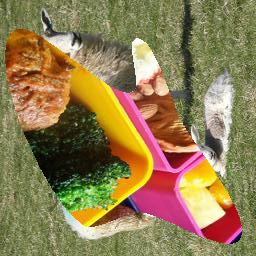

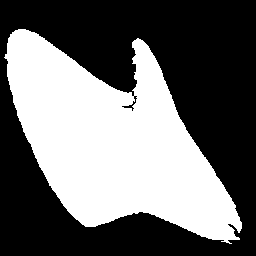

In [14]:
from HiFi_Net import HiFi_Net
from PIL import Image
import numpy as np

HiFi = HiFi_Net()

img_path = "asset/sample_1.jpg"   # image fournie par le repo

# Detection
res, prob = HiFi.detect(img_path)
print("Detection:", res, prob)

# Localization
binary_mask = HiFi.localize(img_path)
mask_img = Image.fromarray((binary_mask * 255).astype(np.uint8))
mask_img.save("pred_mask.png")

display(Image.open(img_path))
display(Image.open("pred_mask.png"))


# **CASIA2**

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
%cd HiFi_IFDL

[Errno 2] No such file or directory: 'HiFi_IFDL'
/content/HiFi_IFDL


In [17]:
!cp "/content/drive/MyDrive/CASIA2.zip" .


In [18]:
ls -lh CASIA2.zip

-r-------- 1 root root 2.6G Feb 12 19:12 CASIA2.zip


In [19]:
with open("CASIA2.zip", "rb") as f:
    signature = f.read(8)

signature


b'PK\x03\x04\x14\x00\x00\x00'

In [20]:
!ls

applications  data_dir		  HiFi_Net_loc.sh    pred_mask.png  weights
asset	      downloaded_weights  HiFi_Net.py	     __pycache__
CASIA2.zip    environment.yml	  IMD_dataloader.py  README.md
center	      figures		  LICENSE	     utils
center_loc    HiFi_Net_loc.py	  models	     viz_eval


In [21]:
import zipfile
import os
!rm -rf CASIA2/
print("no redandent")
!rm -rf "/content/HiFi_IFDL/data_dir/CASIA/CASIA2"
!rm -rf "/content/HiFi_IFDL/mask"
!rm -rf "/content/HiFi_IFDL/fake"
print("previous casia2 dataset deleted")
zip_path = "CASIA2.zip"
extract_path = "/content/HiFi_IFDL/data_dir/CASIA"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Décompression terminée")
print("Contenu :", os.listdir(extract_path))

Casia2_path = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2"
print("Contenu :", os.listdir(Casia2_path))
!mv "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/CASIA 2 Groundtruth" /content/HiFi_IFDL/data_dir/CASIA/CASIA2/mask
!mv "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/Tp" /content/HiFi_IFDL/data_dir/CASIA/CASIA2/fake

no redandent
previous casia2 dataset deleted
Décompression terminée
Contenu : ['__MACOSX', 'CASIA2', 'CASIA1']
Contenu : ['Au', 'CASIA 2 Groundtruth', 'Tp']


# SKANDER TEST

In [22]:
!find data_dir/CASIA/CASIA2/fake -name "*.txt"

data_dir/CASIA/CASIA2/fake/_list.txt


### Testing the casia2



In [23]:
!python HiFi_Net_loc.py -h | head -40
!python HiFi_Net_loc.py -h | grep save
!grep -n "save\|log\|output" /content/HiFi_IFDL/HiFi_Net_loc.py | head -20

2026-02-12 19:13:45.341948: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770923625.529086    1531 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770923625.583682    1531 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770923625.963914    1531 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770923625.963950    1531 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770923625.963955    1531 computation_placer.cc:177] computation placer alr

### create fake.txt from _list.txt

In [24]:
!find data_dir/CASIA/CASIA2/fake -name "*.txt"

data_dir/CASIA/CASIA2/fake/_list.txt


In [25]:
import os

fake_folder = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/fake"
mask_folder = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/mask"
output_file = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/fake.txt"

# Get mask base names (without _gt and extension)
mask_files = set()
for f in os.listdir(mask_folder):
    name = os.path.splitext(f)[0]
    if name.endswith('_gt'):
        name = name[:-3]
    mask_files.add(name)

# Write only fake images that have matching masks
count = 0
skipped = 0
with open(output_file, 'w') as out:
    for f in sorted(os.listdir(fake_folder)):
        if f.endswith(('.tif', '.jpg', '.png', '.bmp')):
            name = os.path.splitext(f)[0]
            if name in mask_files:
                out.write(f + '\n')
                count += 1
            else:
                skipped += 1

print(f"✅ Created fake.txt with {count} images")
print(f"⚠️ Skipped {skipped} images without matching mask")

✅ Created fake.txt with 4981 images
⚠️ Skipped 142 images without matching mask


In [26]:
!find data_dir/CASIA/CASIA2/fake -name "*.txt"

data_dir/CASIA/CASIA2/fake/_list.txt


In [27]:
import os

SAVE_DIR = "outputs_casia2_eval"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- First, create fake.txt with ALL fake images ---
fake_folder = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/fake"
mask_folder = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/mask"
output_file = "/content/HiFi_IFDL/data_dir/CASIA/CASIA2/fake.txt"

# Get mask base names
mask_files = set()
for f in os.listdir(mask_folder):
    if f.endswith('_gt.png'):
        name = f[:-7]  # Remove _gt.png
        mask_files.add(name)

# Only include images with matching masks
count = 0
with open(output_file, 'w') as out:
    for f in sorted(os.listdir(fake_folder)):
        if f.startswith('Tp_') and f.endswith(('.tif', '.jpg', '.png', '.bmp')):
            name = os.path.splitext(f)[0]
            if name in mask_files:
                out.write(f + '\n')
                count += 1

print(f"✅ Created fake.txt with {count} images (full dataset)")

# --- Update ValCasia to use fake.txt and fake folder ---
# Run these sed commands to revert to original paths
!sed -i "s/test_list.txt/fake.txt/g" /content/HiFi_IFDL/utils/load_edata.py
!sed -i "s/'test'/'fake'/g" /content/HiFi_IFDL/utils/load_edata.py

# --- Run evaluation on pre-trained HiFi-Net model ---
!python HiFi_Net_loc.py \
    -l 0 \
    --path data_dir/CASIA/CASIA2 \
    --val_tag 2 \
    --learning_rate 1e-5 2>&1 | tee {SAVE_DIR}/eval_log.txt

print(f"\n✅ Evaluation completed! Logs saved in {SAVE_DIR}/eval_log.txt")

# --- Extract and display results ---
print("\n" + "="*50)
print("EVALUATION RESULTS (Pre-trained HiFi-Net on FULL CASIA2)")
print("="*50)

with open(f"{SAVE_DIR}/eval_log.txt") as f:
    for line in f:
        if "working on" in line.lower() or "F1:" in line or "AUC:" in line:
            print(line.strip())

✅ Created fake.txt with 4981 images (full dataset)
2026-02-12 19:14:13.118535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770923653.139166    1700 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770923653.145970    1700 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770923653.165570    1700 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770923653.165596    1700 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770923653.165600    170